In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

# budowa pipeline
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer

# preprocessong
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures, PowerTransformer
# redukcja wymiarowości
from sklearn.decomposition import PCA
# model
from sklearn.linear_model import LogisticRegression
# ewaluacja
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, f1_score, roc_auc_score

In [24]:
dataset = pd.read_csv('titanic.csv')
dataset

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [25]:
X = dataset.drop(['Survived'], axis=1).copy()
y = dataset['Survived'].copy()
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

In [26]:
# przygotowanie wartości numerycznych
num_features = ['Age', 'SibSp', 'Parch', 'Fare']
num_preparations = Pipeline(steps=[
    ('fill_missings',SimpleImputer(strategy='mean'))
])

In [27]:
print('Surowy zbiór danych - zbiór treningowy:')
print(X_train[num_features].isnull().mean())
X_train_transformed = num_preparations.fit_transform(X_train[num_features])
X_train_transformed = pd.DataFrame(X_train_transformed, columns=num_features)
print('\nWyjście Pipeline - zbiór treningowy')
print(X_train_transformed[num_features].isnull().mean())



Surowy zbiór danych - zbiór treningowy:
Age      0.196108
SibSp    0.000000
Parch    0.000000
Fare     0.000000
dtype: float64

Wyjście Pipeline - zbiór treningowy
Age      0.0
SibSp    0.0
Parch    0.0
Fare     0.0
dtype: float64


In [28]:
print('Surowy zbiór danych - zbiór testowy:')
print(X_test[num_features].isnull().mean())
X_test_transformed = num_preparations.transform(X_test[num_features])
X_test_transformed = pd.DataFrame(X_test_transformed, columns = num_features)
print('\nWyjście Pipeline - zbiór testowy')
print(X_test_transformed[num_features].isnull().mean())

Surowy zbiór danych - zbiór testowy:
Age      0.206278
SibSp    0.000000
Parch    0.000000
Fare     0.000000
dtype: float64

Wyjście Pipeline - zbiór testowy
Age      0.0
SibSp    0.0
Parch    0.0
Fare     0.0
dtype: float64


In [29]:
# transformer = wartości numeryczne oraz kategoryczne
data_preparation = ColumnTransformer(transformers=[
    ('numeric_preprocessing',num_preparations, num_features)
    ])
data_preparation.fit_transform(X_train)

array([[35.    ,  1.    ,  0.    , 90.    ],
       [19.    ,  0.    ,  0.    , 10.5   ],
       [34.    ,  0.    ,  0.    , 13.    ],
       ...,
       [48.    ,  1.    ,  3.    , 34.375 ],
       [47.    ,  0.    ,  0.    , 38.5   ],
       [27.    ,  0.    ,  0.    ,  8.6625]])

In [30]:
class Filter_name(BaseEstimator,TransformerMixin):
    def __init__(self,column):
        self.column = column 
    
    def fit(self,X,y=None):
        return self
    # Override metody rodzica dla fit który na dodatek nic nie robi?
    def transform(self, X, y =None):
        X_transformed = X.copy()
        column = self.column
        X_transformed[column] = X_transformed[column].str.split(', ', expand=True)[1].str.split('.', expand=True)[0]
        X_transformed.loc[~X_transformed[column].isin(['Mr','Miss','Mrs']), column] = 'Other'
        return X_transformed

In [31]:
transformer_filter_name = Filter_name(column='Name')
display(X_train[['Name']])
display(transformer_filter_name.fit_transform(X_train[['Name']]))

cat_features = ['Name','Sex','Embarked']
# przygotowanie wartości kategorycznych
cat_preparation = Pipeline(steps=[
    ('filter_name',Filter_name(column='Name'))
])

print('Przed')
display(X_train[cat_features])
print('Po')
display(cat_preparation.fit_transform(X_train[cat_features]))

,Name
486,"Hoyt, Mrs. Frederick Maxfield (Jane Anne Forby)"
238,"Pengelly, Mr. Frederick William"
722,"Gillespie, Mr. William Henry"
184,"Kink-Heilmann, Miss. Luise Gretchen"
56,"Rugg, Miss. Emily"
...,...
547,"Padro y Manent, Mr. Julian"
469,"Baclini, Miss. Helene Barbara"
736,"Ford, Mrs. Edward (Margaret Ann Watson)"
462,"Gee, Mr. Arthur H"


,Name
486,Mrs
238,Mr
722,Mr
184,Miss
56,Miss
...,...
547,Mr
469,Miss
736,Mrs
462,Mr


Przed


,Name,Sex,Embarked
486,"Hoyt, Mrs. Frederick Maxfield (Jane Anne Forby)",female,S
238,"Pengelly, Mr. Frederick William",male,S
722,"Gillespie, Mr. William Henry",male,S
184,"Kink-Heilmann, Miss. Luise Gretchen",female,S
56,"Rugg, Miss. Emily",female,S
...,...,...,...
547,"Padro y Manent, Mr. Julian",male,C
469,"Baclini, Miss. Helene Barbara",female,C
736,"Ford, Mrs. Edward (Margaret Ann Watson)",female,S
462,"Gee, Mr. Arthur H",male,S


Po


,Name,Sex,Embarked
486,Mrs,female,S
238,Mr,male,S
722,Mr,male,S
184,Miss,female,S
56,Miss,female,S
...,...,...,...
547,Mr,male,C
469,Miss,female,C
736,Mrs,female,S
462,Mr,male,S


In [32]:
# przygotowanie wartości kategorycznych
cat_preparation = Pipeline(steps=[
    ('filter_name', Filter_name(column='Name')),
    ('fill_missings', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])
print(cat_preparation.fit_transform(X_train[cat_features]))
print(cat_preparation.fit_transform(X_train[cat_features]).shape)

[[0. 0. 1. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 1.]
 ...
 [0. 0. 1. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 1.]]
(668, 9)


In [33]:
# transformer = wartości numeryczne oraz kategoryczne
data_prep = ColumnTransformer(transformers=[
    ('numeric_preprocessing', num_preparations, num_features),
    ('categorical_preprocessing', cat_preparation, cat_features)
])
print(data_prep.fit_transform(X_train))
data_prep.fit_transform(X_train).shape

[[35.  1.  0. ...  0.  0.  1.]
 [19.  0.  0. ...  0.  0.  1.]
 [34.  0.  0. ...  0.  0.  1.]
 ...
 [48.  1.  3. ...  0.  0.  1.]
 [47.  0.  0. ...  0.  0.  1.]
 [27.  0.  0. ...  0.  0.  1.]]


(668, 13)

In [34]:
model_pipeline_v1 = Pipeline(steps=[
    ('preprocessing', data_preparation),
    ('model', LogisticRegression(max_iter=10000))
])
model_pipeline_v1.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['PassengerId','Pclass','Name',...,'Fare','Cabin','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric_preprocessing', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

              precision    recall  f1-score   support

           0       0.66      0.89      0.76       137
           1       0.59      0.26      0.36        86

    accuracy                           0.65       223
   macro avg       0.63      0.57      0.56       223
weighted avg       0.63      0.65      0.60       223



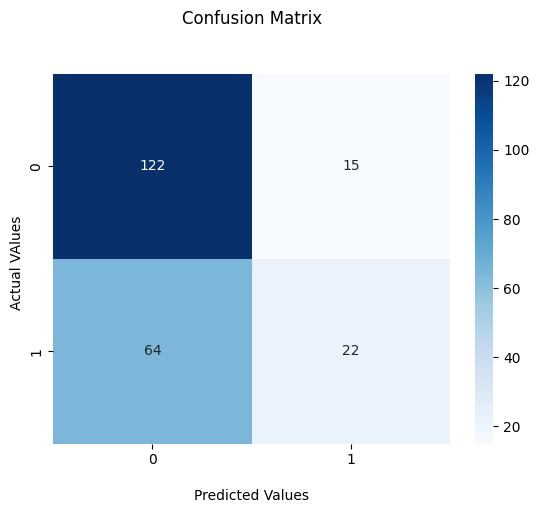

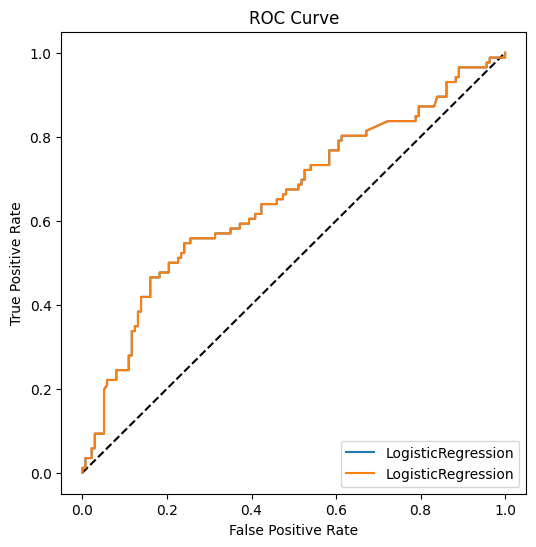

,Model,F1_score,AUC
0,LogisticRegression,0.357724,0.654176
1,LogisticRegression,0.357724,0.654176


In [35]:
from calculate_metrics import calculate_metrics
calculate_metrics(model_pipeline_v1, 'LogisticRegression', X_test, y_test)

              precision    recall  f1-score   support

           0       0.85      0.84      0.84       137
           1       0.75      0.76      0.75        86

    accuracy                           0.81       223
   macro avg       0.80      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223



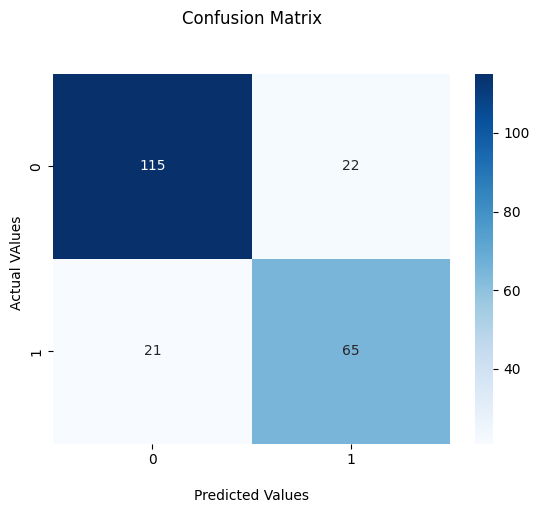

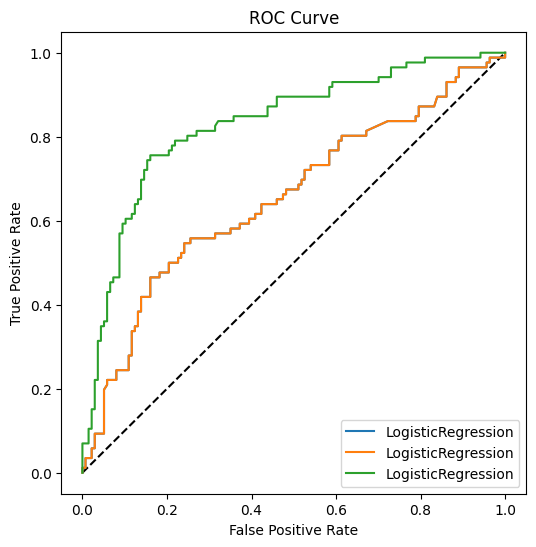

,Model,F1_score,AUC
0,LogisticRegression,0.357724,0.654176
1,LogisticRegression,0.357724,0.654176
2,LogisticRegression,0.751445,0.830207


In [39]:
num_features = ['Age', 'SibSp', 'Parch', 'Fare']
cat_features = ['Name', 'Sex', 'Embarked']

# przygotowanie wartości numerycznych
num_preparation = Pipeline(steps=[
    ('fill_missings', SimpleImputer(strategy='mean')),
    ('polynomial_features', PolynomialFeatures(degree=3)),
    ('scaler_1', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('scaler_2', StandardScaler())
])

# przygotowanie wartości kategorycznych
cat_preparation = Pipeline(steps=[
    ('filter_name', Filter_name(column='Name')),
    ('fill_missings', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(sparse_output=False ,handle_unknown='ignore'))
])

# transformer = wartości numeryczne oraz kategoryczne
data_preparation = ColumnTransformer(transformers=[
    ('numeric_preprocessing', num_preparation, num_features),
    ('categorical_preprocessing', cat_preparation, cat_features)
])

model_pipeline_v2 = Pipeline(steps=[('preprocessor', data_preparation),
                                    ('model', LogisticRegression(max_iter=10000))])
model_pipeline_v2.fit(X_train, y_train)
calculate_metrics(model_pipeline_v2, 'LogisticRegression', X_test, y_test)

In [40]:
model_pipeline_v3 = Pipeline(steps=[('preprocessor', data_preparation),
                                    ('model', LogisticRegression(max_iter=10000))])
list(model_pipeline_v3.get_params().keys())

['memory',
 'steps',
 'transform_input',
 'verbose',
 'preprocessor',
 'model',
 'preprocessor__n_jobs',
 'preprocessor__remainder',
 'preprocessor__sparse_threshold',
 'preprocessor__transformer_weights',
 'preprocessor__transformers',
 'preprocessor__verbose',
 'preprocessor__verbose_feature_names_out',
 'preprocessor__numeric_preprocessing',
 'preprocessor__categorical_preprocessing',
 'preprocessor__numeric_preprocessing__memory',
 'preprocessor__numeric_preprocessing__steps',
 'preprocessor__numeric_preprocessing__transform_input',
 'preprocessor__numeric_preprocessing__verbose',
 'preprocessor__numeric_preprocessing__fill_missings',
 'preprocessor__numeric_preprocessing__polynomial_features',
 'preprocessor__numeric_preprocessing__scaler_1',
 'preprocessor__numeric_preprocessing__pca',
 'preprocessor__numeric_preprocessing__scaler_2',
 'preprocessor__numeric_preprocessing__fill_missings__add_indicator',
 'preprocessor__numeric_preprocessing__fill_missings__copy',
 'preprocessor__

Fitting 5 folds for each of 400 candidates, totalling 2000 fits
Wybrane hiperparametry:  {'model__C': 2.782559402207126, 'preprocessor__numeric_preprocessing__fill_missings__strategy': 'median', 'preprocessor__numeric_preprocessing__pca__n_components': 0.95, 'preprocessor__numeric_preprocessing__polynomial_features__degree': 3}
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       137
           1       0.75      0.76      0.75        86

    accuracy                           0.81       223
   macro avg       0.80      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223



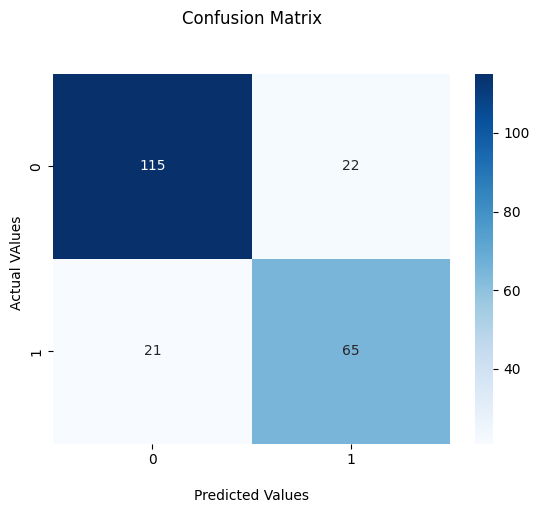

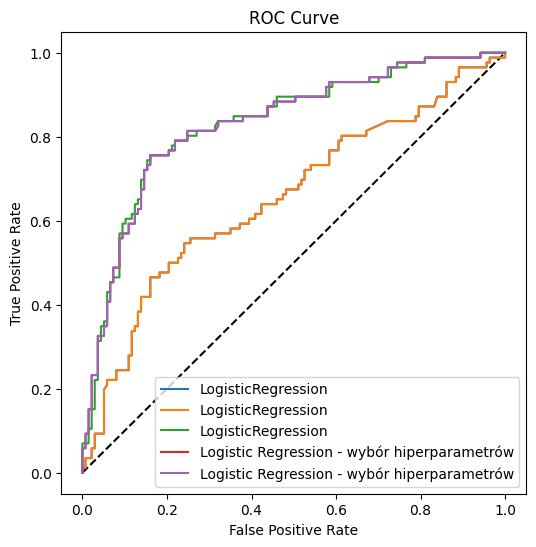

,Model,F1_score,AUC
0,LogisticRegression,0.357724,0.654176
1,LogisticRegression,0.357724,0.654176
2,LogisticRegression,0.751445,0.830207
3,Logistic Regression - wybór hiperparametrów,0.751445,0.830292
4,Logistic Regression - wybór hiperparametrów,0.751445,0.830292


In [44]:
params = {
    'preprocessor__numeric_preprocessing__fill_missings__strategy':['mean','median'],
    'preprocessor__numeric_preprocessing__polynomial_features__degree':[1,2,3,4],
    'preprocessor__numeric_preprocessing__pca__n_components':[0.85,0.90,0.95,0.99,0.99999],
    'model__C':np.logspace(-4,4,10)
}
grid_search = GridSearchCV(model_pipeline_v3,params, cv=5,n_jobs=-1,verbose=5, scoring='f1_macro')
grid_search.fit(X_train,y_train)
print('Wybrane hiperparametry: ', grid_search.best_params_)
model_v3 = grid_search.best_estimator_
calculate_metrics(model_v3, 'Logistic Regression - wybór hiperparametrów', X_test, y_test)